In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------
# 1. DATASET
# ---------------------------------------------------------
# Attributes: Sky, AirTemp, Humidity, Wind, Water, Forecast
attributes = ['Sky', 'AirTemp', 'Humidity', 'Wind', 'Water', 'Forecast']

data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same',   'Yes'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Warm', 'Same',   'Yes'],
    ['Rainy', 'Cold', 'High',   'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Cool', 'Change', 'Yes'],
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)

In [ ]:
def more_general(h1, h2):
    """Return True if h1 is more general than or equal to h2."""
    for x, y_ in zip(h1, h2):
        if x == '?':
            continue
        if x == '0':
            return False
        if x != y_ and y_ != '0':
            return False
    return True


def consistent(h, instance):
    """Check whether hypothesis h matches instance."""
    for hx, ix in zip(h, instance):
        if hx == '?':
            continue
        if hx != ix:
            return False
    return True


def min_generalizations(h, instance):
    """Return minimal generalizations of h that match instance."""
    new_h = list(h)
    for i in range(len(h)):
        if h[i] == '0':
            new_h[i] = instance[i]
        elif h[i] != instance[i]:
            new_h[i] = '?'
    return [tuple(new_h)]


def min_specializations(h, domains, instance):
    """Return minimal specializations of h that do NOT match instance."""
    results = []
    for i in range(len(h)):
        if h[i] == '?':
            for val in domains[i]:
                if val != instance[i]:
                    new_h = list(h)
                    new_h[i] = val
                    results.append(tuple(new_h))
        elif h[i] != '0':
            new_h = list(h)
            new_h[i] = '0'
            results.append(tuple(new_h))
    return results


def remove_more_general(hyps):
    """From a set of hypotheses, remove any that are more general than another (used for S)."""
    return [h for h in hyps if not any(h != h2 and more_general(h2, h) for h2 in hyps)]


def remove_less_general(hyps):
    """From a set of hypotheses, remove any that are less general than another (used for G)."""
    return [h for h in hyps if not any(h != h2 and more_general(h, h2) for h2 in hyps)]

In [ ]:

def candidate_elimination(X, y, attributes):
    domains = [sorted(set(row[i] for row in X)) for i in range(len(attributes))]

    S = [tuple(['0'] * n_attributes)]
    G = [tuple(['?'] * n_attributes)]

    # History for plotting
    history = {
        'S_sizes': [len(S)],
        'G_sizes': [len(G)],
        'S_sets': [list(S)],
        'G_sets': [list(G)],
        'labels': ['Init']
    }

    for idx, (instance, label) in enumerate(zip(X, y)):
        instance = tuple(instance)

        if label == 'Yes':  # Positive example
            G = [g for g in G if consistent(g, instance)]
            new_S = []
            for s in S:
                if consistent(s, instance):
                    new_S.append(s)
                else:
                    generalizations = min_generalizations(s, instance)
                    for h in generalizations:
                        if any(more_general(g, h) for g in G):
                            new_S.append(h)
            S = remove_more_general(list(set(new_S)))

        else:  # Negative example
            S = [s for s in S if not consistent(s, instance)]
            new_G = []
            for g in G:
                if not consistent(g, instance):
                    new_G.append(g)
                else:
                    specializations = min_specializations(g, domains, instance)
                    for h in specializations:
                        if any(more_general(h, s) for s in S):
                            new_G.append(h)
            G = remove_less_general(list(set(new_G)))

        history['S_sizes'].append(len(S))
        history['G_sizes'].append(len(G))
        history['S_sets'].append(list(S))
        history['G_sets'].append(list(G))
        history['labels'].append(f'Ex{idx+1} ({label})')

        print(f"\n--- After Example {idx+1} ({instance} -> {label}) ---")
        print("S (specific boundary):")
        for s in S:
            print("  ", s)
        print("G (general boundary):")
        for g in G:
            print("  ", g)

    return S, G, history


S_final, G_final, history = candidate_elimination(X, y, attributes)

print("\n============================")
print("FINAL SPECIFIC BOUNDARY (S):")
for s in S_final:
    print("  ", s)
print("FINAL GENERAL BOUNDARY (G):")
for g in G_final:
    print("  ", g)


--- After Example 1 (('Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same') -> Yes) ---
S (specific boundary):
   ('Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same')
G (general boundary):
   ('?', '?', '?', '?', '?', '?')

--- After Example 2 (('Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same') -> Yes) ---
S (specific boundary):
   ('Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same')
G (general boundary):
   ('?', '?', '?', '?', '?', '?')

--- After Example 3 (('Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change') -> No) ---
S (specific boundary):
   ('Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same')
G (general boundary):
   ('?', 'Warm', '?', '?', '?', '?')
   ('?', '?', '?', '?', '?', 'Same')
   ('Sunny', '?', '?', '?', '?', '?')

--- After Example 4 (('Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change') -> Yes) ---
S (specific boundary):
   ('Sunny', 'Warm', '?', 'Strong', '?', '?')
G (general boundary):
   ('?', 'Warm', '?', '?', '?', '?')
   ('Sunny', '?', '?', '?', '?', '?')

FINAL SP

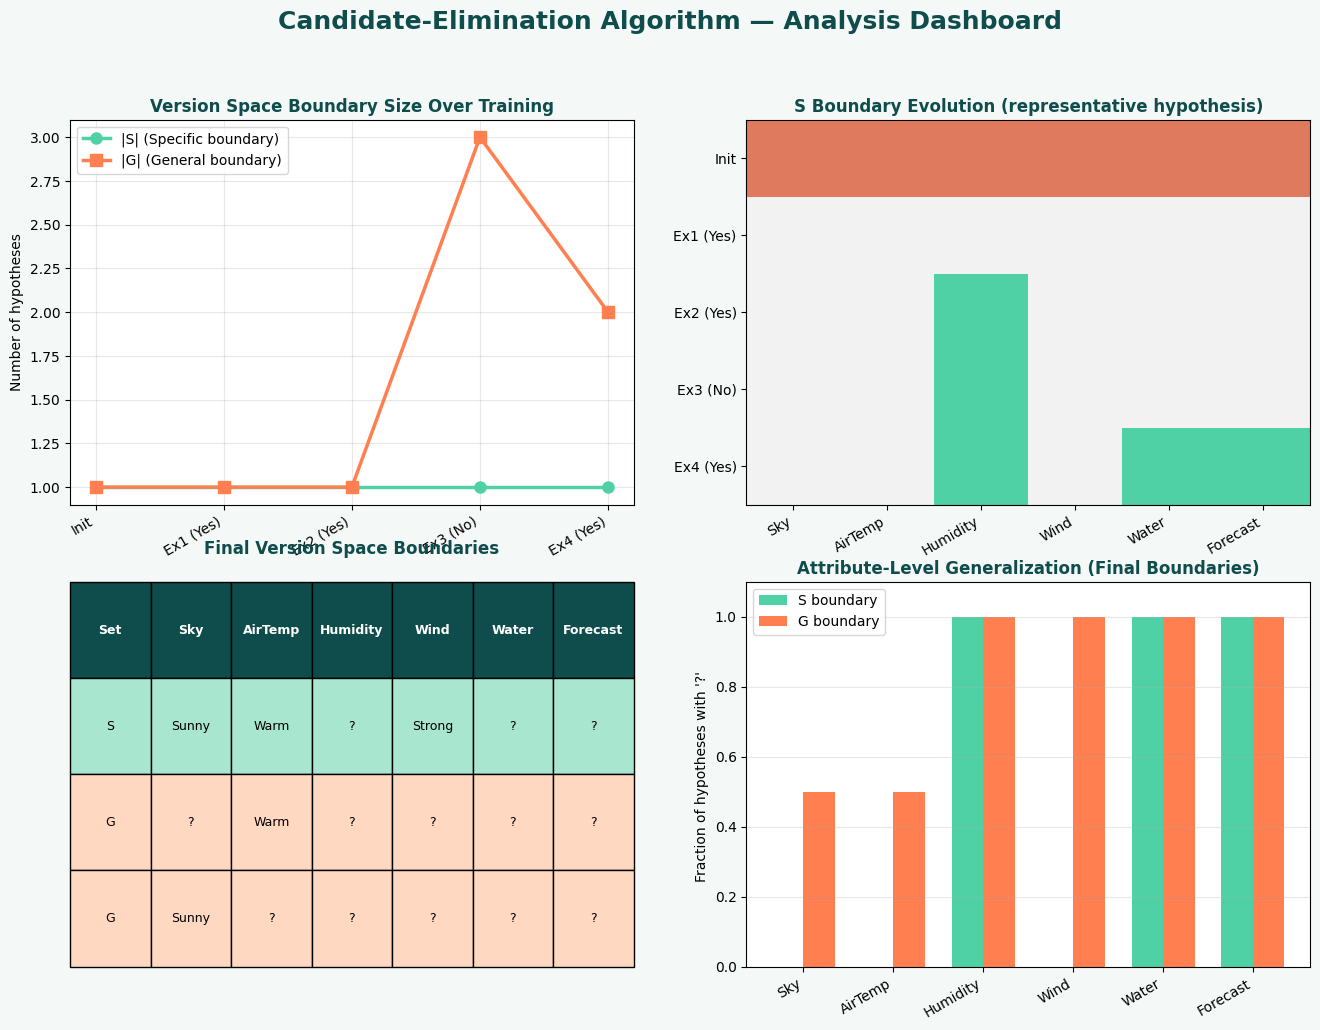

In [ ]:
COL_TEAL = '#0f4c4c'
COL_MINT = '#4fd1a5'
COL_LIGHT = '#a8e6cf'
COL_ACCENT = '#ff7f50'
COL_BG = '#f4f9f8'

def specificity_score(h):
    """Encode a hypothesis into a numeric specificity score.
    0 = most specific attribute value, 1 = '?', -1 = '0' (empty)."""
    return [(-1 if v == '0' else 1 if v == '?' else 0) for v in h]


fig = plt.figure(figsize=(16, 11), facecolor=COL_BG)
fig.suptitle('Candidate-Elimination Algorithm — Analysis Dashboard',
             fontsize=18, fontweight='bold', color=COL_TEAL, y=0.98)

# --- Plot 1: |S| and |G| boundary size trend ---
ax1 = plt.subplot(2, 2, 1)
steps = range(len(history['S_sizes']))
ax1.plot(steps, history['S_sizes'], marker='o', color=COL_MINT, linewidth=2.5,
         label='|S| (Specific boundary)', markersize=8)
ax1.plot(steps, history['G_sizes'], marker='s', color=COL_ACCENT, linewidth=2.5,
         label='|G| (General boundary)', markersize=8)
ax1.set_xticks(steps)
ax1.set_xticklabels(history['labels'], rotation=30, ha='right')
ax1.set_ylabel('Number of hypotheses')
ax1.set_title('Version Space Boundary Size Over Training', color=COL_TEAL, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_facecolor('white')

# --- Plot 2: Specific boundary (S) hypothesis evolution heatmap ---
ax2 = plt.subplot(2, 2, 2)
# Build matrix: rows = steps, cols = attributes, using S[0] at each step (track first S hypothesis)
s_track = []
for s_set in history['S_sets']:
    h = s_set[0] if s_set else tuple(['0'] * n_attributes)
    s_track.append(specificity_score(h))
s_matrix = np.array(s_track)

cmap = ListedColormap(['#e07a5f', '#f2f2f2', COL_MINT])  # -1:empty, 0:specific-value, 1:generalized
im = ax2.imshow(s_matrix, aspect='auto', cmap=cmap, vmin=-1, vmax=1)
ax2.set_xticks(range(n_attributes))
ax2.set_xticklabels(attributes, rotation=30, ha='right')
ax2.set_yticks(range(len(history['labels'])))
ax2.set_yticklabels(history['labels'])
ax2.set_title('S Boundary Evolution (representative hypothesis)', color=COL_TEAL, fontweight='bold')
patches = [
    mpatches.Patch(color='#e07a5f', label="'0' (empty/no value)"),
    mpatches.Patch(color='#f2f2f2', label='specific value'),
    mpatches.Patch(color=COL_MINT, label="'?' (generalized)")
]
ax2.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8)

# --- Plot 3: Final S vs G hypotheses as a table-style comparison ---
ax3 = plt.subplot(2, 2, 3)
ax3.axis('off')
ax3.set_title('Final Version Space Boundaries', color=COL_TEAL, fontweight='bold', pad=20)

table_data = []
row_colors = []
for s in S_final:
    table_data.append(['S'] + list(s))
    row_colors.append(COL_LIGHT)
for g in G_final:
    table_data.append(['G'] + list(g))
    row_colors.append('#ffd8c2')

col_labels = ['Set'] + attributes
tbl = ax3.table(cellText=table_data, colLabels=col_labels, loc='center',
                 cellLoc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for i, color in enumerate(row_colors):
    for j in range(len(col_labels)):
        tbl[(i + 1, j)].set_facecolor(color)
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor(COL_TEAL)
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# --- Plot 4: Attribute-level generality across final S and G ---
ax4 = plt.subplot(2, 2, 4)
s_generality = np.mean([[1 if v == '?' else 0 for v in s] for s in S_final], axis=0)
g_generality = np.mean([[1 if v == '?' else 0 for v in g] for g in G_final], axis=0)

x_pos = np.arange(n_attributes)
width = 0.35
ax4.bar(x_pos - width/2, s_generality, width, label='S boundary', color=COL_MINT)
ax4.bar(x_pos + width/2, g_generality, width, label='G boundary', color=COL_ACCENT)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(attributes, rotation=30, ha='right')
ax4.set_ylabel("Fraction of hypotheses with '?' ")
ax4.set_title('Attribute-Level Generalization (Final Boundaries)', color=COL_TEAL, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')
ax4.set_ylim(0, 1.1)
ax4.set_facecolor('white')


In [ ]:
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('candidate_elimination_analysis.png', dpi=150, facecolor=COL_BG)
plt.show()

print("\nSaved visualization to candidate_elimination_analysis.png")

<Figure size 640x480 with 0 Axes>


Saved visualization to candidate_elimination_analysis.png
